# Twitch Viewer Community Detection at Scale

**Dataset:** [Twitch Interactions dataset (UCSD)](https://cseweb.ucsd.edu/~jmcauley/datasets.html#twitch)

**Research question:** How does shared streamer-viewing behavior form communities in a user network, and how strong are these communities when measured by modularity?

**Method:**
1. Compute pairwise user similarity from shared streamer-viewing history using Jaccard similarity, approximated efficiently with MinHash + LSH (exact all-pairs Jaccard is infeasible at this scale).
2. Build a weighted similarity graph from the resulting edges.
3. Detect communities with the Louvain algorithm (GPU-accelerated via RAPIDS cuGraph) and evaluate community strength with modularity.

This notebook uses the 100k-user subset of the dataset (`100k_a.csv`) for the scaling experiments below; the full dataset can be substituted by uncommenting the relevant download cell.

## Pipeline

`raw interaction logs -> Dask load/filter -> per-user streamer sets -> MinHash + LSH candidate generation -> Jaccard-filtered edge list -> cuGraph Louvain community detection`

Alongside the modeling question, this notebook also benchmarks the pipeline itself: how runtime scales with the number of users (strong scaling) and with the number of Dask workers at a fixed per-worker workload (weak scaling).

## Resources

*   [Twitch Dataset (UCSD)](https://cseweb.ucsd.edu/~jmcauley/datasets.html#twitch)
*   [Dask Documentation](https://docs.dask.org/en/latest/)
*   [RAPIDS cuGraph Documentation](https://docs.rapids.ai/api/cugraph/stable/)
*   [DataSketch MinHash & LSH](https://ekzhu.com/datasketch/)

## Requirements

This notebook is designed for Google Colab with a GPU runtime (T4 or better). It installs RAPIDS (cuDF/cuGraph) and `datasketch` in the first code cell.

## 1. Environment setup

Check the GPU is available, then install RAPIDS (cuDF/cuGraph) and `datasketch` for MinHash LSH.

In [ ]:
!nvidia-smi

Mon Jun  1 10:45:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             54W /  400W |     437MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py
!pip install datasketch

fatal: destination path 'rapidsai-csp-utils' already exists and is not an empty directory.
Installing RAPIDS remaining 26.02 libraries
Using Python 3.12.13 environment at: /usr
Checked 9 packages in 104ms

        ***********************************************************************
        The pip install of RAPIDS is complete.

        Please do not run any further installation from the conda based installation methods, as they may cause issues!

        Please ensure that you're pulling from the git repo to remain updated with the latest working install scripts.

        Troubleshooting:
            - If there is an installation failure, please check back on RAPIDSAI owned templates/notebooks to see how to update your personal files.
            - If an installation failure persists when using the latest script, please make an issue on https://github.com/rapidsai-community/rapidsai-csp-utils
        ***********************************************************************
        


## 2. Data

Download the 100k-user subset of the Twitch interactions dataset. The full dataset (~full_a.csv.gz) can be used instead by uncommenting the corresponding lines below and in the next cell.

In [ ]:
import urllib.request
filename_subset = 'user_streamer_interactions_subset.csv'
# filename_gz = 'user_streamer_interactions_gz.csv.gz'

# Subset dataset
urllib.request.urlretrieve('https://mcauleylab.ucsd.edu/public_datasets/gdrive/twitch/100k_a.csv', filename_subset)

# Full dataset
# urllib.request.urlretrieve('https://mcauleylab.ucsd.edu/public_datasets/gdrive/twitch/full_a.csv.gz', filename_gz)

('user_streamer_interactions_subset.csv',
 <http.client.HTTPMessage at 0x79edb4e4e000>)

In [ ]:
# To unzip the gz file containing the full dataset
# !gunzip -k {filename_gz}

## 3. Pipeline implementation

The pipeline has five stages: Dask-based load/filter, per-user streamer-set construction, MinHash signature generation, LSH candidate lookup, Jaccard-filtered edge construction, and GPU Louvain community detection. Each stage is timed individually so the benchmark cells below can break down where time is spent.

In [ ]:
import time
import gc
import numpy as np
import dask.dataframe as dd
from datasketch import MinHash, MinHashLSH
import cudf
import cugraph
import pandas as pd
from dask.distributed import Client, LocalCluster
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

NUM_PERM = 64
LSH_THRESHOLD = 0.5
JACCARD_FILTER = 0.15

In [ ]:
def dask_stage(number_of_users):
  start = time.time()

  ddf = dd.read_csv(
    filename_subset,
    header=None,
    names=["user_id", "session_id", "streamer_id", "start", "end"],
    usecols=["user_id", "streamer_id"],
    dtype={"user_id": "int32", "streamer_id": "str"},
  ).drop_duplicates()

  sampled_users = (
    ddf["user_id"]
    .drop_duplicates()
    .compute()
    .astype(np.int32)
  )
  selected_users = sampled_users[:number_of_users]

  ddf = ddf[ddf["user_id"].isin(selected_users)]
  pdf = ddf.compute()

  return pdf, time.time() - start

In [ ]:
def run_pipeline(number_of_users):
  stage_times = {}
  start_total = time.time()

  print("Running dask stage")
  pdf, load_time = dask_stage(number_of_users)
  stage_times["load"] = load_time

  t0 = time.time()

  user_streamers = (
    pdf.groupby("user_id")["streamer_id"]
    .apply(set)
    .to_dict()
  )

  stage_times["groupby"] = time.time() - t0

  del pdf
  gc.collect()

  t0 = time.time()

  user_mh = {}
  lsh = MinHashLSH(threshold=LSH_THRESHOLD, num_perm=NUM_PERM)

  print("Running MinHash")
  for u, streams in user_streamers.items():
    m = MinHash(num_perm=NUM_PERM)
    for s in streams:
      m.update(str(s).encode("utf8"))

    user_mh[u] = m
    lsh.insert(str(u), m)

  stage_times["minhash"] = time.time() - t0

  t0 = time.time()

  candidates = set()

  print("Running LSH")
  for u, m in user_mh.items():
    neighbors = lsh.query(m)
    for v in neighbors:
      if v == str(u):
          continue
      v = int(str(v))
      if u < v:
          candidates.add((u, v))

  stage_times["lsh"] = time.time() - t0

  t0 = time.time()

  edges = []
  for u1, u2 in candidates:
    sim = user_mh[u1].jaccard(user_mh[u2])
    if sim >= JACCARD_FILTER:
      edges.append((u1, u2, sim))

  stage_times["jaccard"] = time.time() - t0

  t0 = time.time()

  edges_gdf = cudf.DataFrame(edges, columns=["u1", "u2", "w"])

  G = cugraph.Graph()
  G.from_cudf_edgelist(edges_gdf, "u1", "u2", edge_attr="w")

  result = cugraph.louvain(G)

  comms = result[0]
  modularity = float(result[1])

  stage_times["louvain"] = time.time() - t0
  stage_times["total"] = time.time() - start_total

  del G, edges_gdf, user_streamers, user_mh, candidates
  gc.collect()

  return {
    "users": number_of_users,
    "edges": len(edges),
    "modularity": modularity,
    "minhash": stage_times["minhash"],
    "lsh": stage_times["lsh"],
    "jaccard": stage_times["jaccard"],
    "louvain": stage_times["louvain"],
    "total": stage_times["total"],
  }

## 4. Experiments

Two benchmarks are run against the pipeline above:

- **Strong scaling (by user count):** fixed cluster size (8 workers), increasing user count (25k -> 100k), to see how each pipeline stage and the resulting community structure change as the problem grows.
- **Weak scaling (by worker count):** the per-worker problem size is held fixed (12.5k users/worker) while both worker count and user count scale together (1 worker/12.5k users -> 8 workers/100k users). Ideal weak scaling would keep wall time roughly constant as both dimensions grow together.

In [ ]:
# Test: Increasing user sizes
SIZES = [25000, 50000, 75000, 100000]

user_scaling_results = []
start_all = time.time()

with LocalCluster(
  n_workers=8,
  threads_per_worker=1,
  processes=True
) as cluster:
  with Client(cluster) as client:

    for size in SIZES:
      print(f"\nTest: User scaling on {size} users")
      t0 = time.time()
      output = run_pipeline(number_of_users=size)
      run_time = time.time() - t0
      user_scaling_results.append({
        "users": size,
        "edges": output["edges"],
        "modularity": output["modularity"],
        "minhash_time": output["minhash"],
        "lsh_time": output["lsh"],
        "lsh_query_time": output["lsh"],
        "jaccard_time": output["jaccard"],
        "louvain_time": output["louvain"],
        "total_pipeline_time": output["total"],
        "run_time_wall": run_time
      })
      print(f"Done {size} users in {run_time:.2f}s")
      gc.collect()

print("\nAll scaling tests completed")
print(f"Total time: {time.time() - start_all:.2f}s")

pd.DataFrame(user_scaling_results).to_csv("user_scaling_test_results_final.csv", index=False)


Test: User scaling on 25000 users
Running dask stage
Runing MinHash


Runing LSH


Done 25000 users in 33.30s



Test: User scaling on 50000 users
Running dask stage
Runing MinHash


Runing LSH


...

Done 75000 users in 85.90s

Test: User scaling on 100000 users
Running dask stage


Runing MinHash


Runing LSH


Done 100000 users in 114.03s



All scaling tests completed
Total time: 297.59s


In [ ]:
# Test: Weak scaling
PROBLEM_SIZE_PER_WORKER = 12500
WORKER_SIZES = [1, 2, 4, 8]

full_pipeline_results = []
start_all_full_pipeline = time.time()

for w in WORKER_SIZES:
  num_users = PROBLEM_SIZE_PER_WORKER * w
  print(f"\nTest: weak scaling test on {w} workers, for {num_users} users")

  with LocalCluster(
    n_workers=w,
    threads_per_worker=1,
    processes=True
  ) as cluster:
    with Client(cluster) as client:

      t0 = time.time()

      output = run_pipeline(number_of_users=num_users)

      run_time_wall = time.time() - t0

      full_pipeline_results.append({
        "workers": w,
        "requested_users": num_users,
        "edges": output["edges"],
        "modularity": output["modularity"],
        "minhash_time": output["minhash"],
        "lsh_time": output["lsh"],
        "lsh_query_time": output["lsh"],
        "jaccard_time": output["jaccard"],
        "louvain_time": output["louvain"],
        "total_pipeline_time": output["total"],
        "run_time_wall": run_time_wall
      })

      print(f"Done {w} workers, {num_users} users in {run_time_wall:.2f}s")
      gc.collect()

print("\nAll full pipeline weak scaling runs completed")
print(f"Total time: {time.time() - start_all_full_pipeline:.2f}s")

pd.DataFrame(full_pipeline_results).to_csv("full_pipeline_weak_scaling_results.csv", index=False)


Test: weak scaling test on 1 workers, for 12500 users


Running dask stage
Runing MinHash


Runing LSH


Done 1 workers, 12500 users in 20.40s



Test: weak scaling test on 2 workers, for 25000 users


...


Test: weak scaling test on 8 workers, for 100000 users


Running dask stage
Runing MinHash


Runing LSH


Done 8 workers, 100000 users in 114.50s



All full pipeline weak scaling runs completed
Total time: 234.84s


In [ ]:
print("User scaling results:")
display(pd.DataFrame(user_scaling_results))
print("")
print("Weak scaling results:")
display(pd.DataFrame(full_pipeline_results))

User scaling results:


,users,edges,modularity,minhash_time,lsh_time,lsh_query_time,jaccard_time,louvain_time,total_pipeline_time,run_time_wall
0,25000,86045,0.672561,21.973404,0.688613,0.688613,0.231220,0.155412,32.797643,33.302422
1,50000,351314,0.676104,45.191720,1.651060,1.651060,1.010864,0.378174,57.901908,58.658205
2,75000,736206,0.700661,67.152291,2.786113,2.786113,2.140031,0.712285,84.845944,85.902602
3,100000,1257835,0.704875,90.617015,4.080466,4.080466,3.825091,1.383901,112.599692,114.030814



Weak scaling results:


,workers,requested_users,edges,modularity,minhash_time,lsh_time,lsh_query_time,jaccard_time,louvain_time,total_pipeline_time,run_time_wall
0,1,12500,21372,0.702110,10.999576,0.307117,0.307117,0.054681,0.072752,19.996103,20.395095
1,2,25000,86045,0.672561,21.952346,0.688090,0.688090,0.224997,0.157236,32.385372,32.887718
2,4,50000,351314,0.676104,44.412346,1.608869,1.608869,0.966961,0.379493,58.278508,59.030425
3,8,100000,1257835,0.704875,89.904719,4.101866,4.101866,3.844614,1.358477,113.059883,114.495109


## 5. Results & discussion

First, visualize the stage breakdown, scaling behavior, and modularity trend.

Saved scaling_results.png


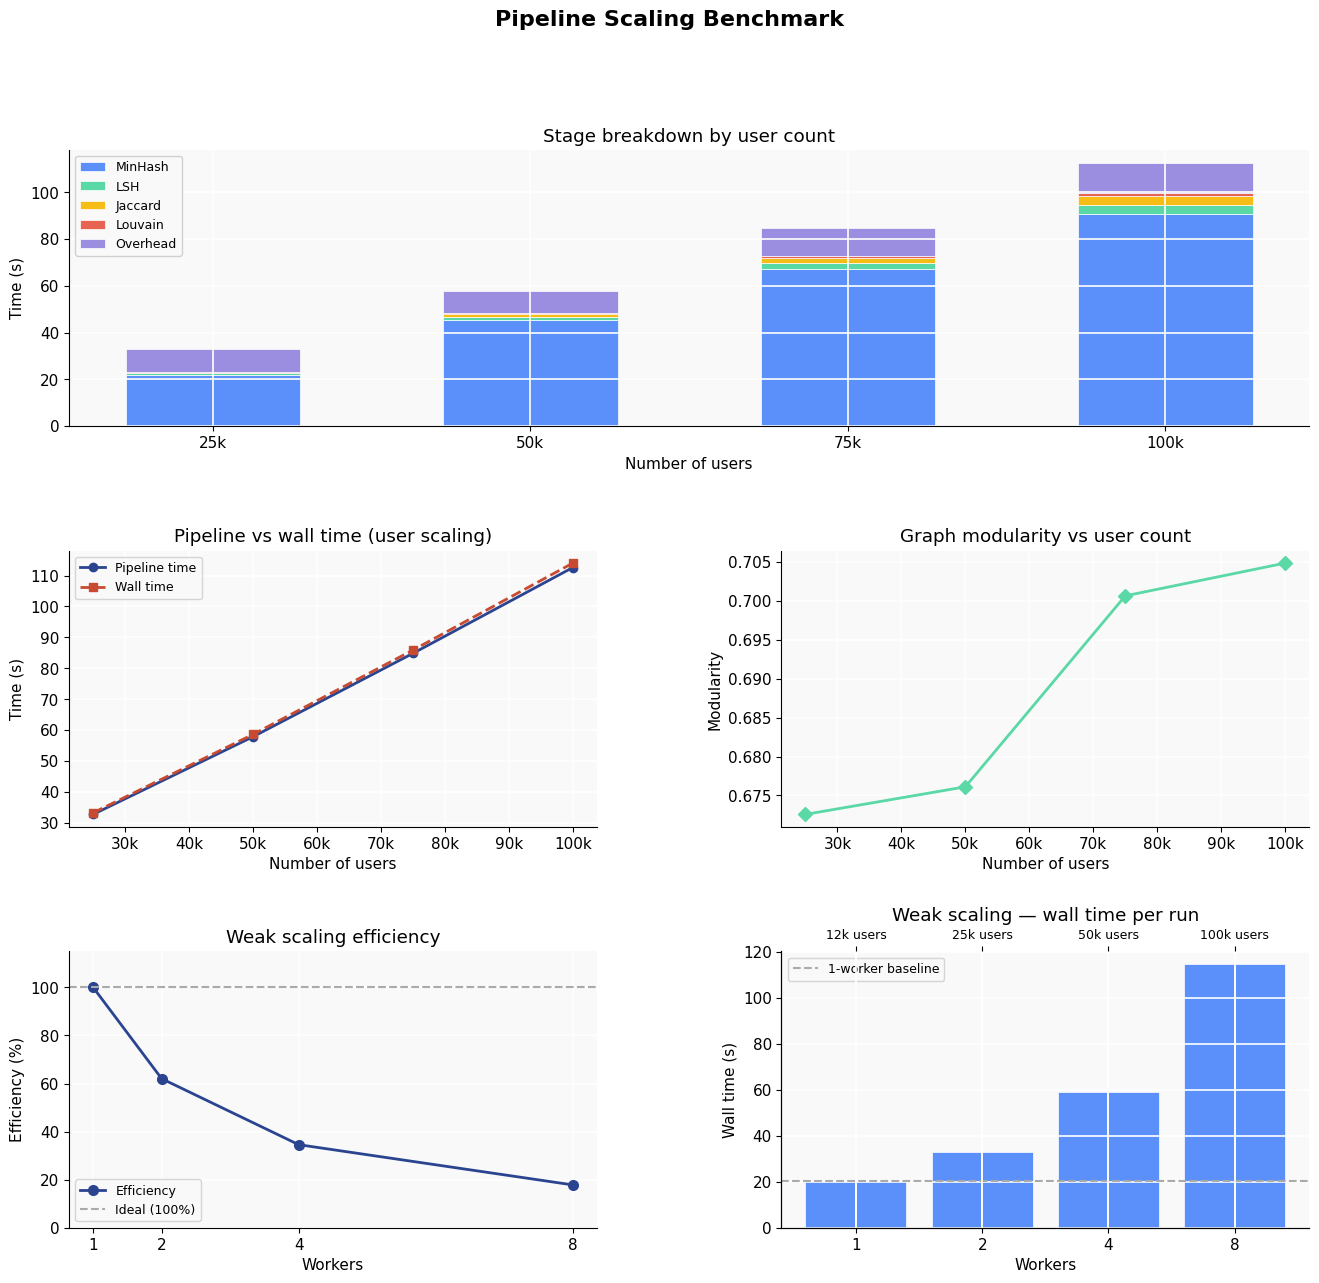

In [ ]:
# Visualizes the benchmark results saved by the two experiment cells above.
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9",
    "axes.grid": True,
    "grid.color": "white",
    "grid.linewidth": 1.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

COLORS = {
    "minhash":  "#5B8FF9",
    "lsh":      "#5AD8A6",
    "jaccard":  "#F6BD16",
    "louvain":  "#E86452",
    "overhead": "#9B8EE0",
    "total":    "#2B4490",
    "wall":     "#C84B31",
    "ideal":    "#aaaaaa",
}

from matplotlib.ticker import FuncFormatter

#  Load data
user_df  = pd.read_csv("user_scaling_test_results_final.csv")
weak_df  = pd.read_csv("full_pipeline_weak_scaling_results.csv")

fig = plt.figure(figsize=(16, 14))
fig.suptitle("Pipeline Scaling Benchmark", fontsize=16, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# 1. Stacked bar - stage breakdown by user count
ax1 = fig.add_subplot(gs[0, :])

stages      = ["minhash_time", "lsh_time", "jaccard_time", "louvain_time"]
stage_labels = ["MinHash", "LSH", "Jaccard", "Louvain"]
stage_colors = [COLORS["minhash"], COLORS["lsh"], COLORS["jaccard"], COLORS["louvain"]]

x       = np.arange(len(user_df))
bottoms = np.zeros(len(user_df), dtype=float)

for col, label, color in zip(stages, stage_labels, stage_colors):
    vals = np.asarray(user_df[col], dtype=float)
    ax1.bar(x, vals, bottom=bottoms, label=label, color=color, width=0.55, edgecolor="white", linewidth=0.5)
    bottoms += vals

# Overhead = total − sum of known stages
known_sum = user_df[stages].sum(axis=1)
overhead  = (user_df["total_pipeline_time"] - known_sum).clip(lower=0)
ax1.bar(x, overhead, bottom=bottoms, label="Overhead", color=COLORS["overhead"],
        width=0.55, edgecolor="white", linewidth=0.5)

ax1.set_xticks(x)
ax1.set_xticklabels([f"{u//1000}k" for u in user_df["users"]])
ax1.set_xlabel("Number of users")
ax1.set_ylabel("Time (s)")
ax1.set_title("Stage breakdown by user count")
ax1.legend(loc="upper left", framealpha=0.9, fontsize=9)

# 2. Wall time vs pipeline time
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(user_df["users"], user_df["total_pipeline_time"], "o-",
         color=COLORS["total"], label="Pipeline time", linewidth=2, markersize=6)
ax2.plot(user_df["users"], user_df["run_time_wall"], "s--",
         color=COLORS["wall"], label="Wall time", linewidth=2, markersize=6)
ax2.set_xlabel("Number of users")
ax2.set_ylabel("Time (s)")
ax2.set_title("Pipeline vs wall time (user scaling)")
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v)//1000}k"))

# 3. Modularity vs user count
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(user_df["users"], user_df["modularity"], "D-",
         color=COLORS["lsh"], linewidth=2, markersize=7)
ax3.set_xlabel("Number of users")
ax3.set_ylabel("Modularity")
ax3.set_title("Graph modularity vs user count")
ax3.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v)//1000}k"))

# 4. Weak scaling efficiency
ax4 = fig.add_subplot(gs[2, 0])

base_time = weak_df.iloc[0]["run_time_wall"]
efficiency = base_time / weak_df["run_time_wall"] * 100

ax4.plot(weak_df["workers"], efficiency, "o-",
         color=COLORS["total"], linewidth=2, markersize=7, label="Efficiency")
ax4.axhline(100, color=COLORS["ideal"], linestyle="--", linewidth=1.5, label="Ideal (100%)")
ax4.set_xlabel("Workers")
ax4.set_ylabel("Efficiency (%)")
ax4.set_title("Weak scaling efficiency")
ax4.set_xticks(weak_df["workers"])
ax4.set_ylim(0, 115)
ax4.legend(fontsize=9)

# 5. Weak scaling - absolute wall time
ax5 = fig.add_subplot(gs[2, 1])
ax5.bar(weak_df["workers"].astype(str), weak_df["run_time_wall"],
        color=COLORS["minhash"], edgecolor="white", linewidth=0.5)
ax5.axhline(base_time, color=COLORS["ideal"], linestyle="--", linewidth=1.5, label="1-worker baseline")
ax5.set_xlabel("Workers")
ax5.set_ylabel("Wall time (s)")
ax5.set_title("Weak scaling - wall time per run")
ax5.legend(fontsize=9)

# Secondary x-axis: users per bar in weak scaling
ax5b = ax5.twiny()
ax5b.set_xlim(ax5.get_xlim())
ax5b.set_xticks(range(len(weak_df)))
ax5b.set_xticklabels([f"{u//1000}k users" for u in weak_df["requested_users"]], fontsize=9)
ax5b.spines["top"].set_visible(False)

plt.savefig("scaling_results.png", dpi=150, bbox_inches="tight")
print("Saved scaling_results.png")
plt.show()

## Discussion

**Community structure improves with scale.** Modularity rises from 0.67 at 25k users to 0.70 at 100k users, meaning the detected communities become proportionally denser than the graph would expect from a random baseline as more of the network is observed. This is consistent with the similarity graph being genuinely community-structured rather than sparse noise: more data reveals the underlying structure more clearly rather than diluting it.

**Edge count grows faster than linearly with user count** (86k edges at 25k users vs. 1.26M edges at 100k users, a ~14.6x increase for a 4x increase in users). This is expected: with `LSH_THRESHOLD = 0.5` and `JACCARD_FILTER = 0.15`, more users means more candidate pairs pass the similarity filter, and the LSH/Jaccard stages scale accordingly, which is visible in `lsh_time` and `jaccard_time` both growing roughly with edge count rather than user count.

**The bottleneck is MinHash construction, not GPU graph clustering.** At 100k users, `minhash_time` is ~90.6s out of a ~112.6s total pipeline time (80%), while GPU Louvain (`louvain_time`) takes only ~1.4s. The RAPIDS/cuGraph investment pays off exactly where expected - clustering is cheap once the graph is built - but the actual cost center is the pure-Python per-user MinHash loop. A faster next step would be vectorizing or GPU-accelerating signature generation (e.g. with `cuDF`/custom hashing) rather than further optimizing the graph stage.

**Weak scaling is poor, and the reason is visible in the pipeline structure.** Ideal weak scaling would keep wall time roughly flat as workers and problem size grow together (1 worker/12.5k users vs. 8 workers/100k users). Instead, wall time grows from 20.4s to 114.5s - about a 5.6x increase for the same per-worker workload, or ~18% efficiency at 8 workers. This is because `dask_stage` is the only Dask-parallelized part of the pipeline: it computes to a plain pandas DataFrame (`pdf = ddf.compute()`), after which MinHash construction, LSH insertion/query, and Jaccard filtering all run single-threaded in plain Python dictionaries, unaffected by `n_workers`. Adding more Dask workers speeds up the initial load/filter but does nothing for the stage that actually dominates runtime - which is consistent with the first finding above. Distributing the MinHash/LSH stage itself (e.g. via `dask.bag` or partitioned Dask DataFrames) would be the natural fix.

**Takeaway:** the graph algorithm (Louvain on cuGraph) was never the scaling risk here - the sequential candidate-generation step was. This kind of stage-by-stage profiling is what surfaced that, and would be the first place to invest engineering effort before scaling to the full dataset.